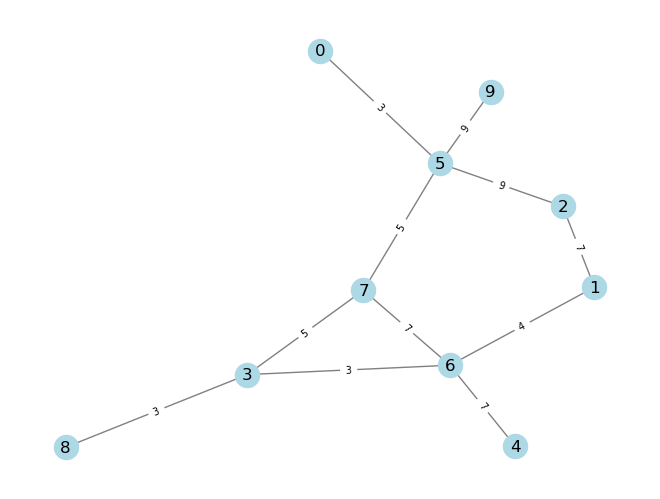

In [181]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from Graphs.plot_weights_graph import PlotWeightsGraph as PWG

matrix = np.loadtxt('Graphs/test_graph_with_weights.txt', dtype=int)

G = nx.from_numpy_array(matrix)


simpleTestEdges = [(1, 2, 2), (1, 3, 3), (2, 3, 1,), (3, 5, 5), (3, 4, 1)]
simpleTestGraph = nx.Graph()
simpleTestGraph.add_weighted_edges_from(simpleTestEdges)
#G = simpleTestGraph

plt.show(PWG(G))

In [182]:
def count_total_weight(graph):
    total_weight = 0
    for u, v, data in graph.edges(data=True):
        total_weight += data.get('weight', 0)
    return total_weight

print("Total weight of the graph:", count_total_weight(G))

Total weight of the graph: 62


In [183]:
edge_sets = []
for u, v, data in G.edges(data=True):
    edge_sets.append(([u, v, data.get('weight', 0)]))

sorted_edge_sets = sorted(edge_sets, key=lambda x: x[2])

print("Edge sets with weights:", sorted_edge_sets)

Edge sets with weights: [[0, 5, 3], [3, 6, 3], [3, 8, 3], [1, 6, 4], [3, 7, 5], [5, 7, 5], [1, 2, 7], [4, 6, 7], [6, 7, 7], [2, 5, 9], [5, 9, 9]]


In [184]:
MST_edges = []

for u, v, weight in sorted_edge_sets:
    if len(MST_edges) == 0: MST_edges.append((u, v, weight))

    if (u in [edge[0] for edge in MST_edges] and v in [edge[1] for edge in MST_edges]): continue
    else: MST_edges.append((u, v, weight))

print("MST edges:", MST_edges)

MST edges: [(0, 5, 3), (3, 6, 3), (3, 8, 3), (1, 6, 4), (3, 7, 5), (5, 7, 5), (1, 2, 7), (4, 6, 7), (6, 7, 7), (2, 5, 9), (5, 9, 9)]


MST Adjacency Matrix:
 [[0 0 0 0 0 3 0 0 0 0]
 [0 0 7 0 0 0 4 0 0 0]
 [0 7 0 0 0 9 0 0 0 0]
 [0 0 0 0 0 0 3 5 3 0]
 [0 0 0 0 0 0 7 0 0 0]
 [3 0 9 0 0 0 0 5 0 9]
 [0 4 0 3 7 0 0 7 0 0]
 [0 0 0 5 0 5 7 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 0 0 0 0 9 0 0 0 0]]


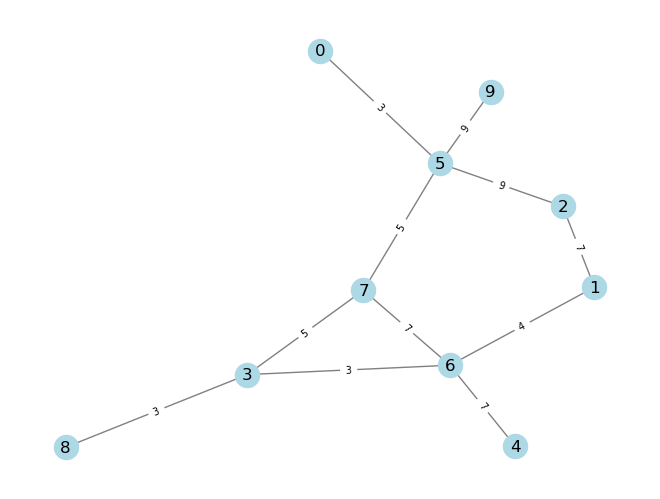

In [185]:
def edges_to_matrix(edge_list, num_nodes=None):
    if num_nodes is None:
        num_nodes = max(max(u, v) for u, v, w in edge_list) + 1

    matrix = np.zeros((num_nodes, num_nodes), dtype=int)

    for u, v, weight in edge_list:
        matrix[u][v] = weight
        matrix[v][u] = weight  

    return matrix


MST_matrix = edges_to_matrix(MST_edges)
print("MST Adjacency Matrix:\n", MST_matrix)
PWG(nx.from_numpy_array(MST_matrix))